In [21]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)
            print(f"Found file at: {file_path}")

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month_name()

print("Success! Data Loaded.")
df.head()

Found file at: /kaggle/input/datasets/kinzaemannn/unemployment-in-india/Unemployment in India.csv
Success! Data Loaded.


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September


In [18]:

print("Initial Data Types:")
print(df.dtypes)

df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Frequency'] = df['Frequency'].astype('category')
df['Region'] = df['Region'].astype('category')
df['Area'] = df['Area'].astype('category')

df['Month'] = df['Date'].dt.month_name()
df['Month_int'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nCleaned Data Types:")
print(df.dtypes)
df.head()

Initial Data Types:
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
Month                                              object
dtype: object

Missing values after cleaning:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
Month                                      28
Month_int                                  28
Year                                       28
dtype: int

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Month_int,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,5.0,2019.0
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,6.0,2019.0
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,7.0,2019.0
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,8.0,2019.0
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,9.0,2019.0


In [8]:
df_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()
fig = px.line(df_trend, x='Date', y='Estimated Unemployment Rate (%)', 
              title='Average Unemployment Rate Trend in India',
              markers=True)
fig.add_vrect(x0="2020-03-25", x1="2020-06-30", 
              fillcolor="red", opacity=0.1, line_width=0,
              annotation_text="COVID-19 Lockdown", annotation_position="top left")

fig.update_layout(xaxis_title='Date', yaxis_title='Mean Unemployment Rate (%)')
fig.show()

In [9]:
df_region = df.groupby(['Date', 'Region'])['Estimated Unemployment Rate (%)'].mean().reset_index()
fig = px.area(df_region, x="Date", y="Estimated Unemployment Rate (%)", color="Region",
              title="Regional Unemployment Trends: Impact of COVID-19",
              line_group="Region", 
              hover_data={'Date': '|%B %Y', 'Estimated Unemployment Rate (%)': ':.2f%'})
fig.add_vrect(x0="2020-03-25", x1="2020-06-30", 
              fillcolor="gray", opacity=0.2, line_width=0,
              annotation_text="National Lockdown", annotation_position="top left")

fig.update_layout(
    xaxis_title="Timeline",
    yaxis_title="Unemployment Rate (%)",
    legend_title="Region",
    font=dict(family="Arial", size=12)
)

fig.show()

In [15]:

fig = px.histogram(df, x='Region', y='Estimated Unemployment Rate (%)', color='Area',
                   barmode='group', title='Average Unemployment Rate: Rural vs Urban')
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

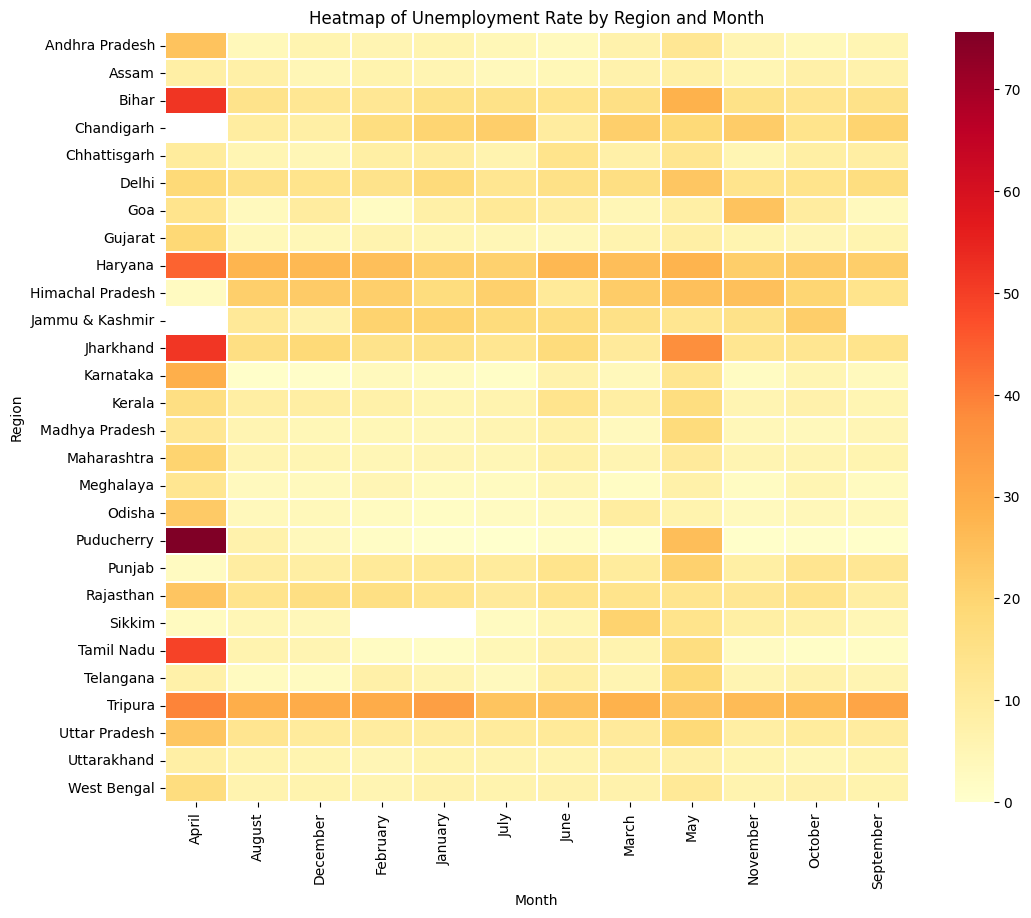

In [14]:

pivot_table = df.pivot_table(index='Region', columns='Month', 
                             values='Estimated Unemployment Rate (%)', aggfunc='mean')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, annot=False, cmap='YlOrRd', linewidths=0.1)
plt.title('Heatmap of Unemployment Rate by Region and Month')
plt.xlabel('Month')
plt.ylabel('Region')
plt.show()

In [22]:
lockdown_start = '2020-03-01'
before_lockdown = df[df['Date'] < lockdown_start]
during_lockdown = df[df['Date'] >= lockdown_start]
avg_before = before_lockdown['Estimated Unemployment Rate (%)'].mean()
avg_during = during_lockdown['Estimated Unemployment Rate (%)'].mean()
pct_increase = ((avg_during - avg_before) / avg_before) * 100

print(f"Average Unemployment Rate Before Lockdown: {avg_before:.2f}%")
print(f"Average Unemployment Rate During/After Lockdown: {avg_during:.2f}%")
print(f"Percentage Increase in Unemployment: {pct_increase:.2f}%")
comparison_df = pd.DataFrame({
    'Period': ['Before Lockdown', 'During/After Lockdown'],
    'Average Unemployment Rate (%)': [avg_before, avg_during]
})

fig = px.bar(comparison_df, x='Period', y='Average Unemployment Rate (%)', 
             color='Period', title='Impact of COVID-19 on Average Unemployment Rate')
fig.show()

Average Unemployment Rate Before Lockdown: 9.51%
Average Unemployment Rate During/After Lockdown: 17.77%
Percentage Increase in Unemployment: 86.91%
